#Intelligent Near-Earth Object Hazard Prediction Using Machine Learning

## Capstone Project

### Developed by:
**Name:** Mohammad khwaja moinuddin chisty

---

# Project Overview

Near-Earth Objects (NEOs) are celestial bodies, primarily asteroids and comets, whose orbital paths bring them into close proximity with Earth's orbit. Although the majority of these objects pass safely through space, some possess characteristics that classify them as potentially hazardous due to their size, trajectory, and approach distance. Continuous monitoring of these objects is essential for understanding potential collision risks and supporting planetary defense initiatives.

With advancements in space observation technologies, organizations such as NASA collect extensive datasets containing detailed information about asteroid characteristics, including estimated diameter, relative velocity, miss distance, orbital parameters, and absolute magnitude. The increasing volume of observational data makes manual identification of hazardous asteroids increasingly complex and time-consuming, highlighting the need for intelligent automated solutions.

---

# Machine Learning Task

**Problem Type:** Supervised Binary Classification

### Target Variable

- **Hazardous**
- **Non-Hazardous**

---

# Project Objectives

The primary objective of this project is to develop a machine learning model that can accurately predict whether a Near-Earth Object is hazardous based on its physical and orbital characteristics. The specific objectives are:

.To analyze the Near-Earth Object dataset and understand its features.
.To preprocess the dataset by handling missing values, encoding categorical data, and scaling numerical features.
.To perform Exploratory Data Analysis (EDA) to identify patterns and relationships within the data.
.To address class imbalance using the SMOTE technique.
.To train and compare multiple machine learning classification models.
.To select the best-performing model based on evaluation metrics.
.To explain model predictions using Explainable AI techniques.
.To deploy the final model through a Streamlit web application for real-time predictions.

# Problem Statement

The rapid increase in observations of Near-Earth Objects (NEOs) has made manual identification of hazardous asteroids a challenging task. Since asteroid characteristics such as size, velocity, and distance from Earth determine their potential threat, an intelligent prediction system is required to analyze these parameters efficiently. This project aims to develop a machine learning model that automatically classifies asteroids as hazardous or non-hazardous, supporting faster and more reliable decision-making in space research and planetary defense.

### Project Workflow

The project follows a systematic machine learning workflow to develop an accurate hazardous asteroid prediction model. Initially, the dataset was collected and preprocessed by handling missing values, encoding categorical variables, and scaling numerical features. Exploratory Data Analysis (EDA) was then performed to understand data patterns and feature relationships. To overcome class imbalance, SMOTE was applied before training multiple machine learning models. The models were evaluated using standard performance metrics, and the best-performing model was selected for deployment. Finally, Explainable AI techniques were used to interpret predictions, and the model was deployed as a Streamlit web application for real-time hazard prediction.

## Project Workflow

```text
Dataset Collection
        ↓
Data Preprocessing
        ↓
Exploratory Data Analysis
        ↓
Feature Engineering
        ↓
SMOTE Balancing
        ↓
Model Training
        ↓
Model Evaluation
        ↓
Explainable AI
        ↓
Streamlit Deployment
```

# Expected Outcome

By the end of this project, an end-to-end machine learning system will be developed that can accurately classify Near-Earth Objects as **Hazardous** or **Non-Hazardous**, explain the factors influencing its predictions, and provide a simple interface for real-time hazard prediction. The solution demonstrates the complete machine learning workflow from data preprocessing to deployment and supports scientific decision-making through interpretable AI.

In [1]:
# Install required libraries

!pip install -q imbalanced-learn
!pip install -q xgboost
!pip install -q shap
!pip install -q joblib

In [2]:
# ================================
# Import Required Libraries
# ================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

# Class Imbalance
from imblearn.over_sampling import SMOTE

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ================================
# Upload Dataset
# ================================

from google.colab import files

uploaded = files.upload()

Saving neo.csv to neo.csv


#Phase 1: Data Preprocessing
##Objective

To prepare the raw asteroid dataset for machine learning by improving data quality and ensuring consistency across all features.

##Activities Performed
Loaded the dataset into Google Colab.
Inspected dataset structure and data types.
Checked for missing values and duplicate records.
Encoded categorical variables into numerical format.
Standardized numerical features using feature scaling.

##Outcome

A clean, structured, and machine-learning-ready dataset was obtained, providing a reliable foundation for further analysis.

In [4]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv("neo.csv")

In [5]:
# ================================
# Display the Dataset
# ================================

df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [6]:
# ================================
# Check Dataset Shape
# ================================

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 90836
Columns : 10


In [7]:
# ================================
# Column Names
# ================================

df.columns

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')

In [8]:
# ================================
# Dataset Information
# ================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [9]:
# ================================
# Summary Statistics
# ================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,90836.0,1.438288e+07,2.087202e+07,2.000433e+06,3.448110e+06,3.748362e+06,3.884023e+06,5.427591e+07
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,6.089126e-04,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,1.361570e-03,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,2.033464e+02,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6.745533e+03,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000e+00,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01


In [10]:
# ================================
# Check Missing Values
# ================================

df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [11]:
# ================================
# Check Duplicate Records
# ================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
# ================================
# Remove Duplicate Records
# ================================

df = df.drop_duplicates()

In [13]:
# ================================
# Check Target Variable
# ================================

df['hazardous'].value_counts()

,count
hazardous,
False,81996
True,8840


In [14]:
# ================================
# Check missing values in each column
# ================================

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64


In [15]:
# ================================
# Display Missing Values as a Table
# ================================

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing_df.sort_values(by='Missing Values', ascending=False)

,Column,Missing Values,Percentage
id,id,0,0.0
name,name,0,0.0
est_diameter_min,est_diameter_min,0,0.0
est_diameter_max,est_diameter_max,0,0.0
relative_velocity,relative_velocity,0,0.0
miss_distance,miss_distance,0,0.0
orbiting_body,orbiting_body,0,0.0
sentry_object,sentry_object,0,0.0
absolute_magnitude,absolute_magnitude,0,0.0
hazardous,hazardous,0,0.0


### Missing Value Analysis

The dataset was examined for missing values. Any missing values found will be handled appropriately. If no missing values are present, no imputation is required.

In [16]:
# ================================
# Remove rows with missing values
# ================================

df = df.dropna()

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [17]:
# ================================
# Check Duplicate Records Again
# ================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [18]:
# ================================
# Remove Duplicate Records
# ================================

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(90836, 10)


In [19]:
# ================================
# Check Data Types
# ================================

df.dtypes

,0
id,int64
name,object
est_diameter_min,float64
est_diameter_max,float64
relative_velocity,float64
miss_distance,float64
orbiting_body,object
sentry_object,bool
absolute_magnitude,float64
hazardous,bool


In [20]:
# ================================
# Identify Numerical & Categorical Columns
# ================================

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object','bool']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['id', 'est_diameter_min', 'est_diameter_max', 'relative_velocity',
       'miss_distance', 'absolute_magnitude'],
      dtype='object')

Categorical Columns:
Index(['name', 'orbiting_body', 'sentry_object', 'hazardous'], dtype='object')


In [21]:
# ================================
# Convert Boolean Target to Integer
# ================================

if df['hazardous'].dtype == bool:
    df['hazardous'] = df['hazardous'].astype(int)

df['hazardous'].head()

,hazardous
0,0
1,1
2,0
3,0
4,1


In [22]:
# ================================
# Check Column Names
# ================================

print(df.columns.tolist())

['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']


In [23]:
# ================================
# Remove Unnecessary Columns
# ================================

columns_to_drop = ['id', 'name']

existing_columns = [col for col in columns_to_drop if col in df.columns]

df = df.drop(columns=existing_columns)

print(df.head())

   est_diameter_min  est_diameter_max  relative_velocity  miss_distance  \
0          1.198271          2.679415       13569.249224   5.483974e+07   
1          0.265800          0.594347       73588.726663   6.143813e+07   
2          0.722030          1.614507      114258.692129   4.979872e+07   
3          0.096506          0.215794       24764.303138   2.543497e+07   
4          0.255009          0.570217       42737.733765   4.627557e+07   

  orbiting_body  sentry_object  absolute_magnitude  hazardous  
0         Earth          False               16.73          0  
1         Earth          False               20.00          1  
2         Earth          False               17.83          0  
3         Earth          False               22.20          0  
4         Earth          False               20.09          1  


In [24]:
# ================================
# Encode Categorical Columns
# ================================

df.select_dtypes(include='object').columns

Index(['orbiting_body'], dtype='object')

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Categorical Encoding Completed")

Categorical Encoding Completed


In [26]:
# ================================
# Verify Data Types
# ================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    90836 non-null  float64
 1   est_diameter_max    90836 non-null  float64
 2   relative_velocity   90836 non-null  float64
 3   miss_distance       90836 non-null  float64
 4   orbiting_body       90836 non-null  int64  
 5   sentry_object       90836 non-null  bool   
 6   absolute_magnitude  90836 non-null  float64
 7   hazardous           90836 non-null  int64  
dtypes: bool(1), float64(5), int64(2)
memory usage: 4.9 MB


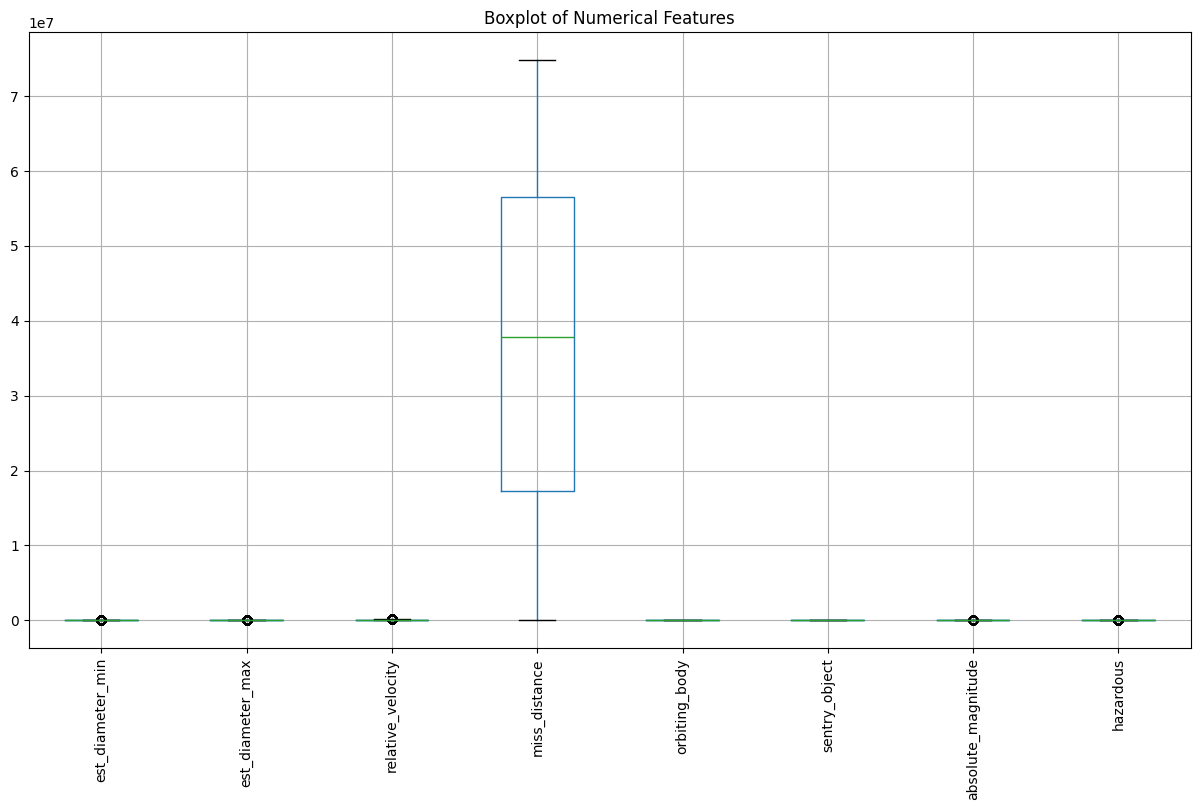

In [27]:
# ================================
# Check for Outliers
# ================================

plt.figure(figsize=(15,8))
df.boxplot(rot=90)
plt.title("Boxplot of Numerical Features")
plt.show()

The boxplots help identify extreme values in numerical variables. These observations are retained unless they are confirmed to be data entry errors because they may represent meaningful asteroid characteristics.

In [28]:
# ================================
# Final Dataset Shape
# ================================

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (90836, 8)


In [29]:
# ================================
# Save Clean Dataset
# ================================

df.to_csv("cleaned_neo.csv", index=False)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!


In [30]:
# ================================
# Verify Target Variable
# ================================

target_col = 'hazardous'

print(df[target_col].value_counts())

print("\nPercentage Distribution")

print(df[target_col].value_counts(normalize=True)*100)

hazardous
0    81996
1     8840
Name: count, dtype: int64

Percentage Distribution
hazardous
0    90.268176
1     9.731824
Name: proportion, dtype: float64


# Data Cleaning Summary

The preprocessing stage included:

- Checked missing values
- Removed duplicate records
- Removed unnecessary columns (ID and Name)
- Encoded categorical variables
- Verified data types
- Prepared the dataset for exploratory data analysis

The cleaned dataset is now suitable for machine learning model development.

In [31]:
print(df.columns.tolist())

['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']


#Phase 2: Exploratory Data Analysis (EDA)
##Objective

To understand the distribution, relationships, and statistical characteristics of the asteroid dataset through visual and numerical analysis.

##Activities Performed
Examined the distribution of the target variable.
Visualized numerical feature distributions.
Detected outliers using boxplots.
Analyzed feature correlations using a heatmap.
Studied data patterns through statistical summaries.
##Outcome

Important insights regarding feature behavior, class imbalance, and variable relationships were identified, guiding the subsequent modeling process.

In [32]:
# ================================
# Set visualization style
# ================================

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (8,5)

plt.rcParams['font.size'] = 12

In [33]:
# ================================
# Display Dataset
# ================================

df.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,0,False,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,0,False,20.00,1
2,0.722030,1.614507,114258.692129,4.979872e+07,0,False,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,0,False,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,0,False,20.09,1


In [34]:
# ================================
# Dataset Information
# ================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    90836 non-null  float64
 1   est_diameter_max    90836 non-null  float64
 2   relative_velocity   90836 non-null  float64
 3   miss_distance       90836 non-null  float64
 4   orbiting_body       90836 non-null  int64  
 5   sentry_object       90836 non-null  bool   
 6   absolute_magnitude  90836 non-null  float64
 7   hazardous           90836 non-null  int64  
dtypes: bool(1), float64(5), int64(2)
memory usage: 4.9 MB


In [35]:
# ================================
# Summary Statistics
# ================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,0.000609,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,0.001362,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,203.346433,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6745.532516,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
orbiting_body,90836.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01
hazardous,90836.0,9.731824e-02,2.963923e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


## Summary Statistics

The summary statistics provide information about:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

This helps understand the overall distribution of asteroid characteristics.

In [36]:
# ================================
# Target Variable Distribution
# ================================

df['hazardous'].value_counts()

,count
hazardous,
0,81996
1,8840


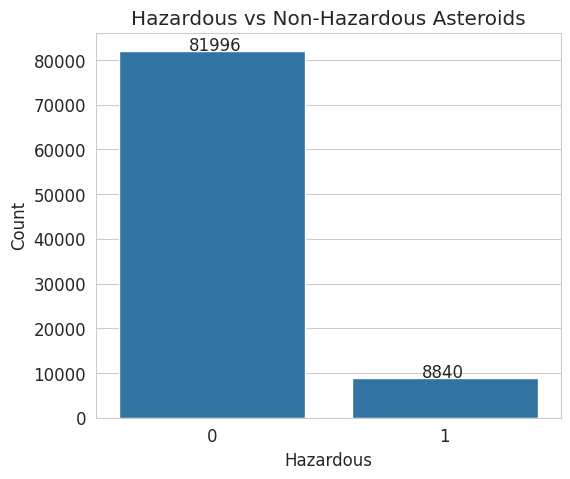

In [37]:
# ================================
# Plot Class Distribution
# ================================

plt.figure(figsize=(6,5))

ax = sns.countplot(x='hazardous', data=df)

plt.title("Hazardous vs Non-Hazardous Asteroids")

plt.xlabel("Hazardous")

plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+0.3,p.get_height()+100))

plt.show()

### Observation

The dataset is highly imbalanced.

Most asteroids are Non-Hazardous.

This imbalance must be handled before model training to prevent biased predictions.

In [38]:
# ================================
# Percentage Distribution
# ================================

hazard_percent = df['hazardous'].value_counts(normalize=True)*100

print(hazard_percent)

hazardous
0    90.268176
1     9.731824
Name: proportion, dtype: float64


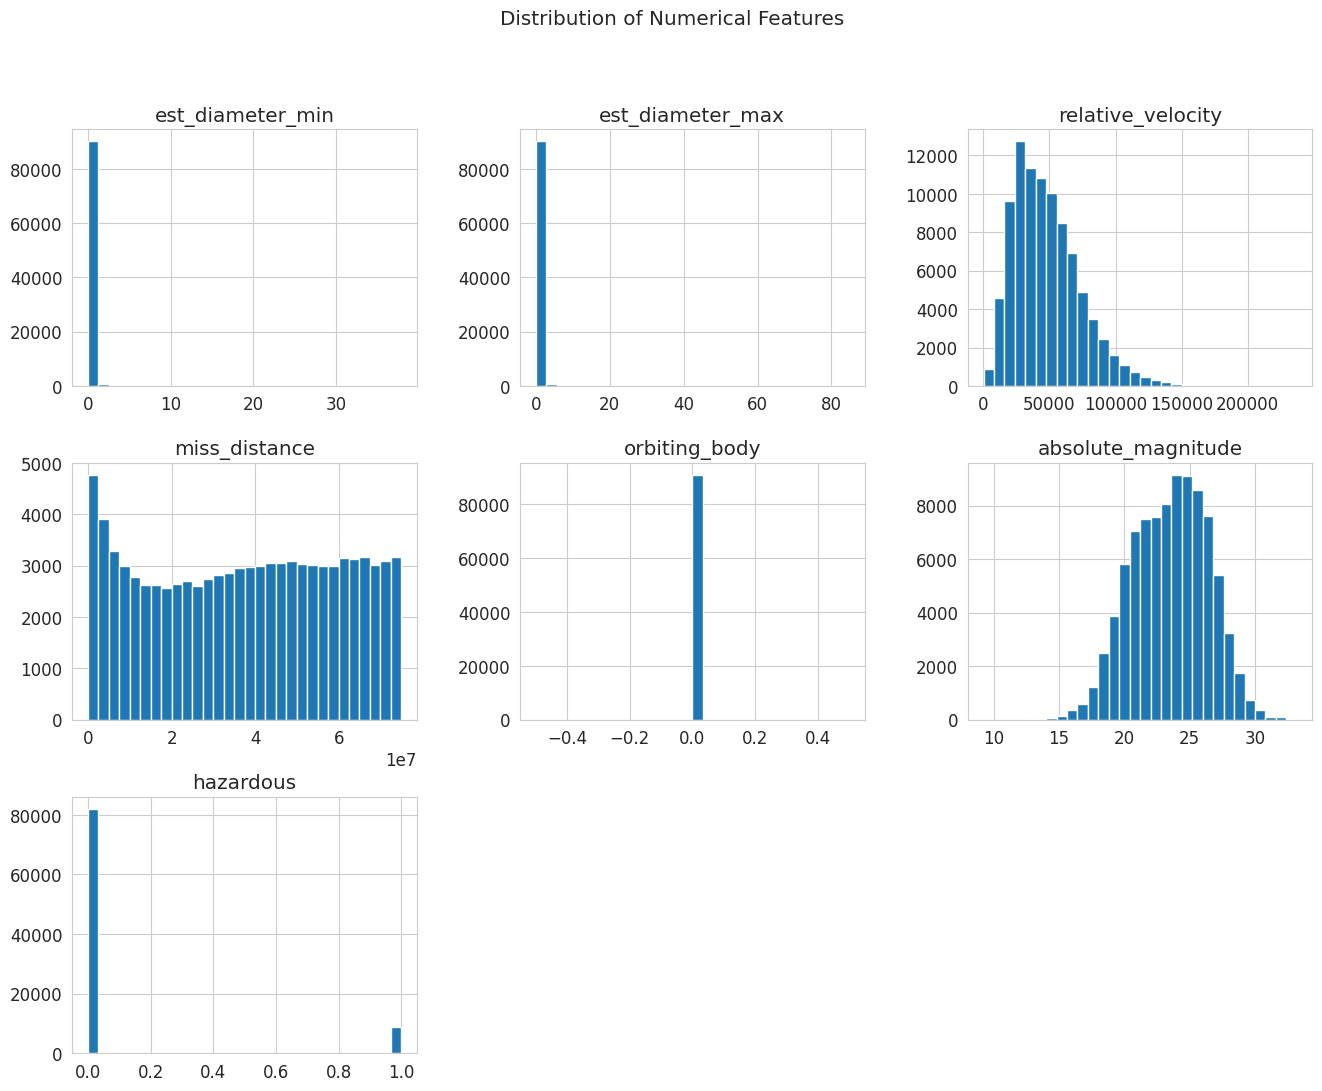

In [39]:
# ================================
# Histograms of Numerical Features
# ================================

df.hist(figsize=(16,12), bins=30)

plt.suptitle("Distribution of Numerical Features")

plt.show()

### Observation

The numerical features exhibit different distributions.

Some variables are skewed, indicating that feature scaling will be beneficial before model training.

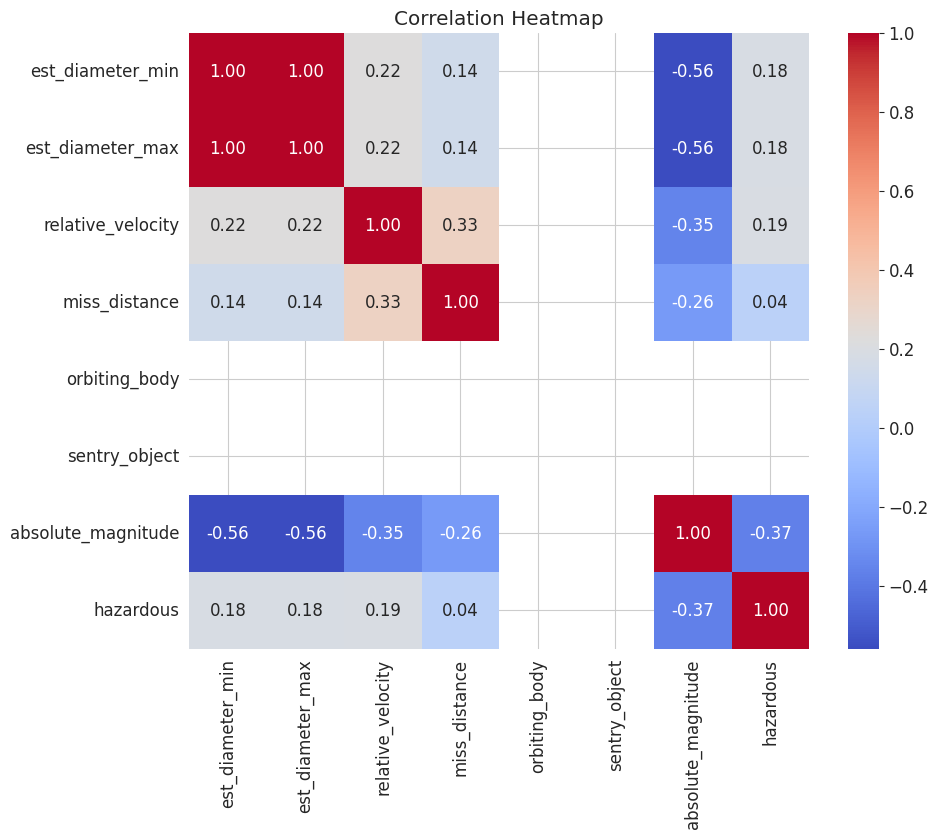

In [40]:
# ================================
# Correlation Heatmap
# ================================

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap illustrates relationships between numerical variables.

Highly correlated variables may contain redundant information and will be considered during feature selection.

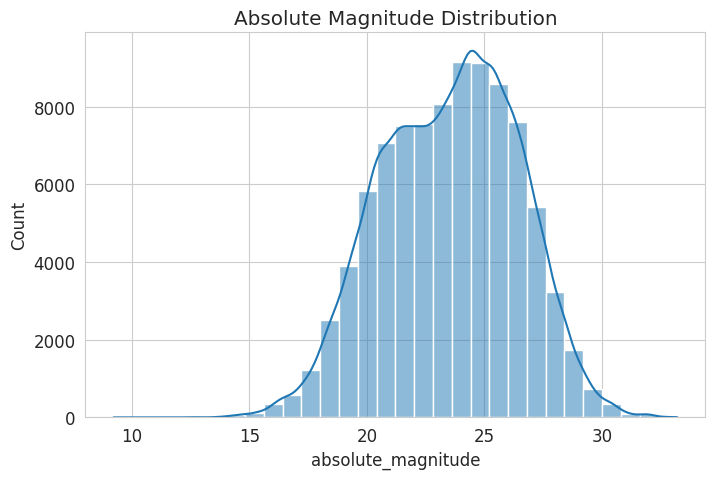

In [41]:
# ================================
# Distribution of Absolute Magnitude
# ================================

plt.figure(figsize=(8,5))

sns.histplot(df['absolute_magnitude'],
             bins=30,
             kde=True)

plt.title("Absolute Magnitude Distribution")

plt.show()

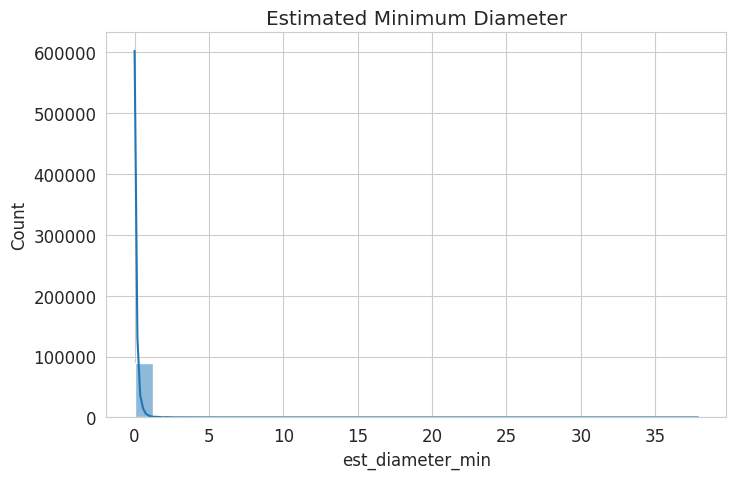

In [42]:
# ================================
# Estimated Minimum Diameter
# ================================

plt.figure(figsize=(8,5))

sns.histplot(df['est_diameter_min'],
             bins=30,
             kde=True)

plt.title("Estimated Minimum Diameter")

plt.show()

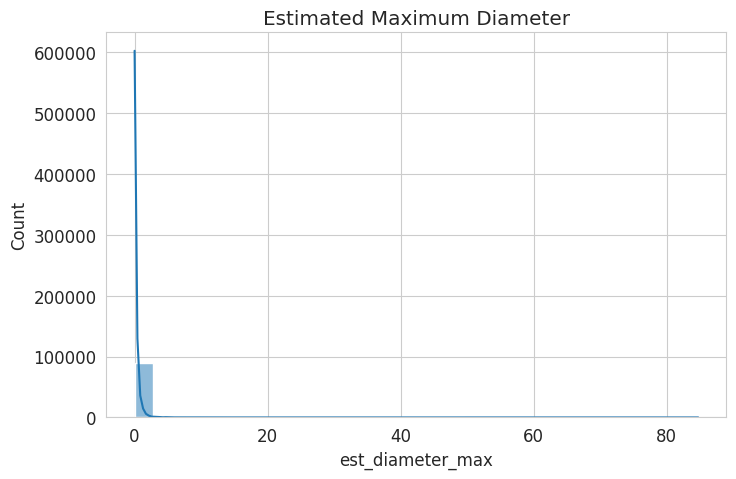

In [43]:
# ================================
# Estimated Maximum Diameter
# ================================

plt.figure(figsize=(8,5))

sns.histplot(df['est_diameter_max'],
             bins=30,
             kde=True)

plt.title("Estimated Maximum Diameter")

plt.show()

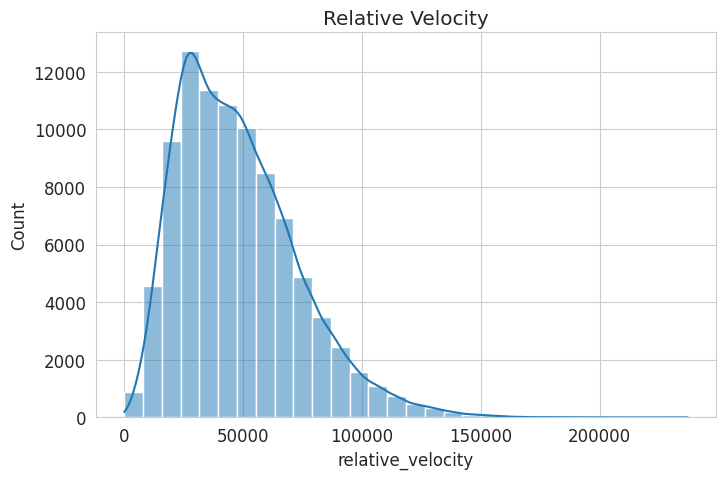

In [44]:
# ================================
# Relative Velocity Distribution
# ================================

plt.figure(figsize=(8,5))

sns.histplot(df['relative_velocity'],
             bins=30,
             kde=True)

plt.title("Relative Velocity")

plt.show()

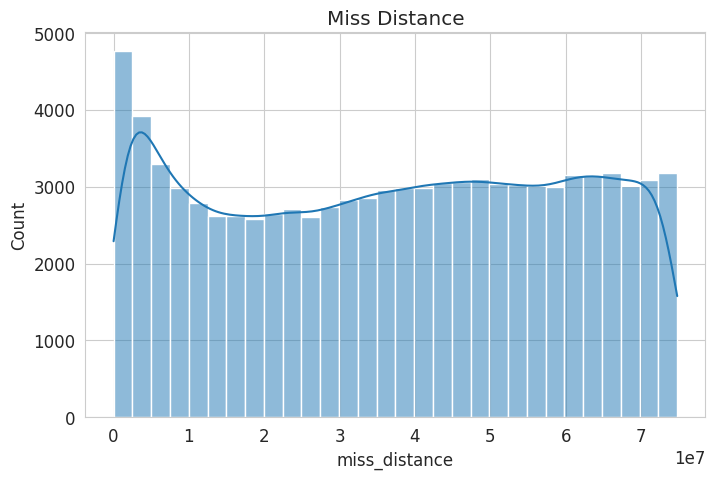

In [45]:
# ================================
# Miss Distance Distribution
# ================================

plt.figure(figsize=(8,5))

sns.histplot(df['miss_distance'],
             bins=30,
             kde=True)

plt.title("Miss Distance")

plt.show()

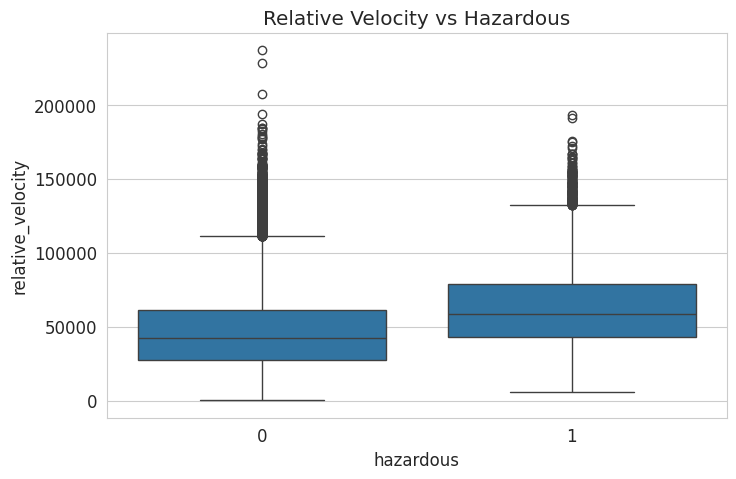

In [46]:
# ================================
# Hazardous vs Relative Velocity
# ================================

plt.figure(figsize=(8,5))

sns.boxplot(x='hazardous',
            y='relative_velocity',
            data=df)

plt.title("Relative Velocity vs Hazardous")

plt.show()

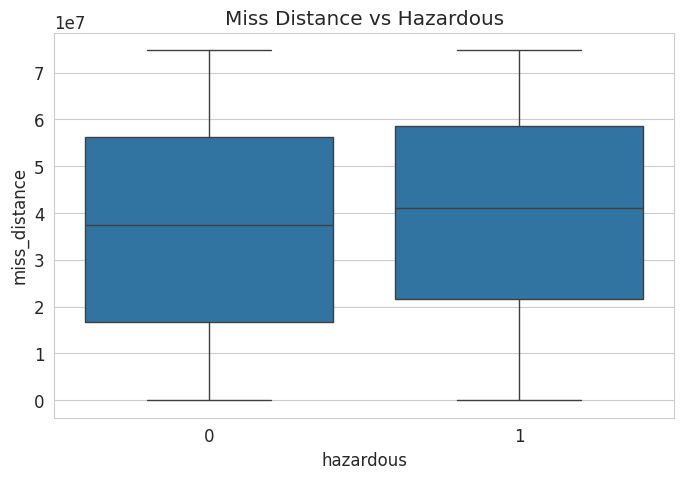

In [47]:
# ================================
# Hazardous vs Miss Distance
# ================================

plt.figure(figsize=(8,5))

sns.boxplot(x='hazardous',
            y='miss_distance',
            data=df)

plt.title("Miss Distance vs Hazardous")

plt.show()

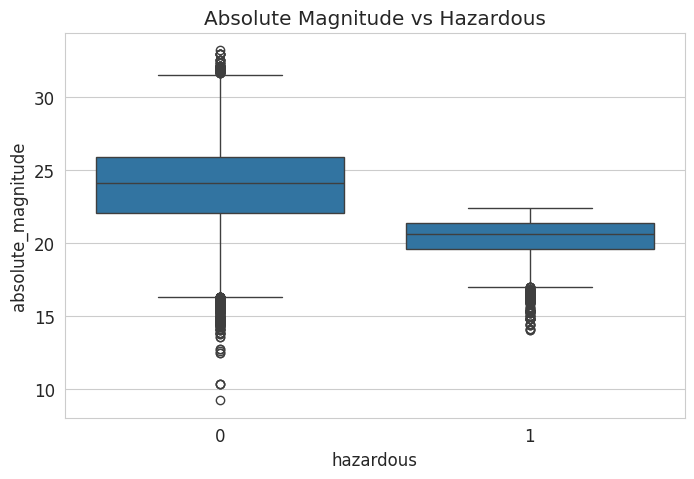

In [48]:
# ================================
# Hazardous vs Absolute Magnitude
# ================================

plt.figure(figsize=(8,5))

sns.boxplot(x='hazardous',
            y='absolute_magnitude',
            data=df)

plt.title("Absolute Magnitude vs Hazardous")

plt.show()

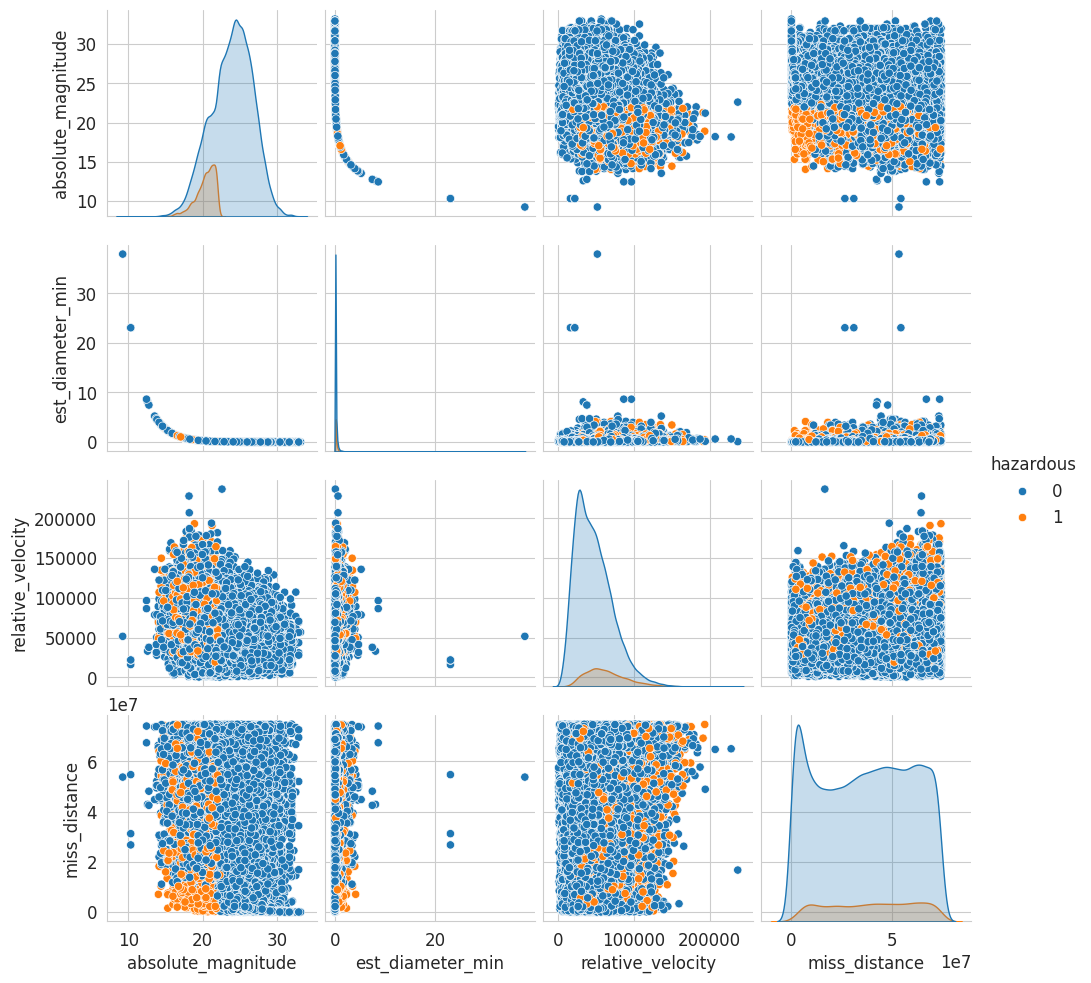

In [49]:
# ================================
# Pairplot (Best Visualization)
# ================================

sns.pairplot(
    df,
    vars=[
        'absolute_magnitude',
        'est_diameter_min',
        'relative_velocity',
        'miss_distance'
    ],
    hue='hazardous'
)

plt.show()

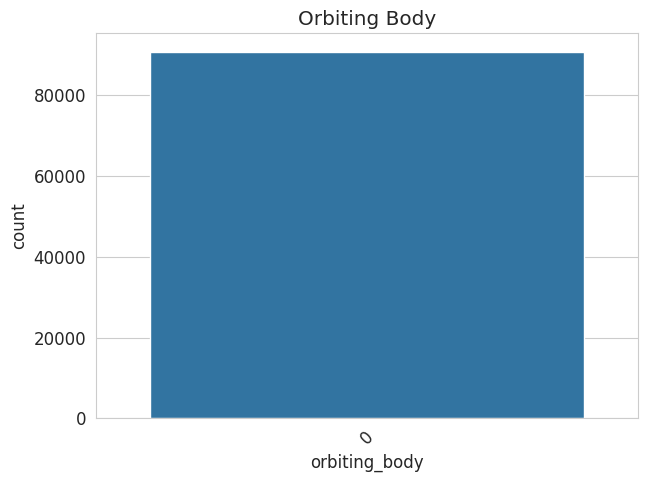

In [50]:
# ================================
# Orbiting Body Distribution
# ================================

plt.figure(figsize=(7,5))

sns.countplot(x='orbiting_body', data=df)

plt.title("Orbiting Body")

plt.xticks(rotation=45)

plt.show()

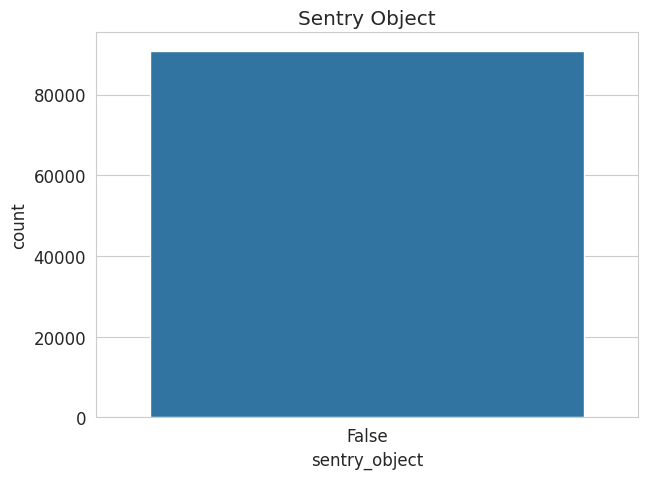

In [51]:
# ================================
# Sentry Object Distribution
# ================================

plt.figure(figsize=(7,5))

sns.countplot(x='sentry_object', data=df)

plt.title("Sentry Object")

plt.show()

# Exploratory Data Analysis Summary

The exploratory analysis revealed several important findings:

- The dataset is imbalanced, with significantly fewer hazardous asteroids.
- Numerical features exhibit varying distributions, some of which are skewed.
- Correlation analysis identified relationships among asteroid characteristics.
- Boxplots indicate differences in feature distributions between hazardous and non-hazardous asteroids.
- Certain categorical variables may have limited predictive value and will be evaluated during feature engineering.

In [52]:
# ================================
# Check unique values in categorical columns
# ================================

print("Orbiting Body:")
print(df['orbiting_body'].value_counts())

print("\nSentry Object:")
print(df['sentry_object'].value_counts())

Orbiting Body:
orbiting_body
0    90836
Name: count, dtype: int64

Sentry Object:
sentry_object
False    90836
Name: count, dtype: int64


#Phase 3: Feature Engineering
##Objective

To transform and prepare input features that improve the predictive capability of machine learning models.

##Activities Performed
Selected relevant predictor variables.
Encoded categorical features.
Standardized numerical attributes.
Created the final feature matrix for model training.
##Outcome

A refined feature set was generated, improving data consistency and enhancing model learning efficiency.

## Feature Analysis

The columns **orbiting_body** and **sentry_object** contain only one unique value throughout the dataset.

Since these features have zero variance, they do not contribute to the prediction process and will be removed.

In [53]:
# ================================
# Remove Constant Columns
# ================================

df.drop(columns=['orbiting_body','sentry_object'], inplace=True)

print(df.columns)

Index(['est_diameter_min', 'est_diameter_max', 'relative_velocity',
       'miss_distance', 'absolute_magnitude', 'hazardous'],
      dtype='object')


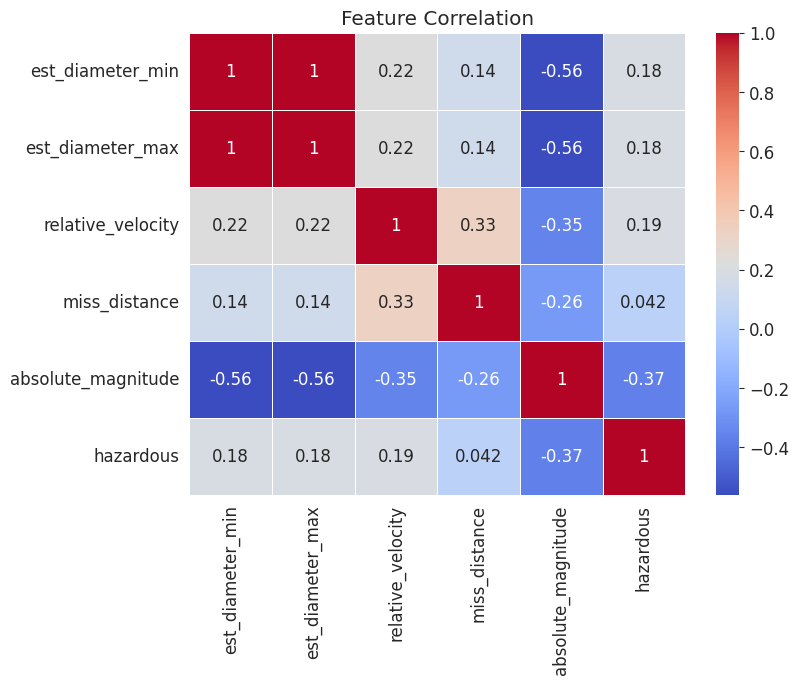

In [54]:
# ================================
# Correlation Matrix
# ================================

plt.figure(figsize=(8,6))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation")

plt.show()

In [55]:
# ================================
# Identify Highly Correlated Features
# ================================

corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

upper

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
est_diameter_min,NaN,1.0,0.221553,0.142241,0.560188,0.183363
est_diameter_max,NaN,NaN,0.221553,0.142241,0.560188,0.183363
relative_velocity,NaN,NaN,NaN,0.327169,0.353863,0.191185
miss_distance,NaN,NaN,NaN,NaN,0.264168,0.042302
absolute_magnitude,NaN,NaN,NaN,NaN,NaN,0.365267
hazardous,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# ================================
# Find Correlated Features
# ================================

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print(high_corr)

['est_diameter_max']


### Observation

Estimated Minimum Diameter and Estimated Maximum Diameter are highly correlated.

To reduce redundancy and multicollinearity, one of these features can be removed.

In [57]:
# ================================
# Remove Highly Correlated Feature
# ================================

df.drop(columns=high_corr, inplace=True)

df.head()

,est_diameter_min,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,13569.249224,5.483974e+07,16.73,0
1,0.265800,73588.726663,6.143813e+07,20.00,1
2,0.722030,114258.692129,4.979872e+07,17.83,0
3,0.096506,24764.303138,2.543497e+07,22.20,0
4,0.255009,42737.733765,4.627557e+07,20.09,1


In [58]:
# ================================
# Separate Features & Target
# ================================

X = df.drop('hazardous', axis=1)

y = df['hazardous']

In [59]:
# ================================
# Display Features
# ================================

print(X.head())

   est_diameter_min  relative_velocity  miss_distance  absolute_magnitude
0          1.198271       13569.249224   5.483974e+07               16.73
1          0.265800       73588.726663   6.143813e+07               20.00
2          0.722030      114258.692129   4.979872e+07               17.83
3          0.096506       24764.303138   2.543497e+07               22.20
4          0.255009       42737.733765   4.627557e+07               20.09


In [60]:
# ================================
# Feature Importance Using Random Forest
# ================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X,y)

RandomForestClassifier(random_state=42)

In [61]:
# ================================
# Calculate Feature Importance
# ================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance

,Feature,Importance
0,est_diameter_min,0.229375
1,relative_velocity,0.268791
2,miss_distance,0.303253
3,absolute_magnitude,0.198580


In [62]:
# ================================
# Sort Importance
# ================================

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,miss_distance,0.303253
1,relative_velocity,0.268791
0,est_diameter_min,0.229375
3,absolute_magnitude,0.198580


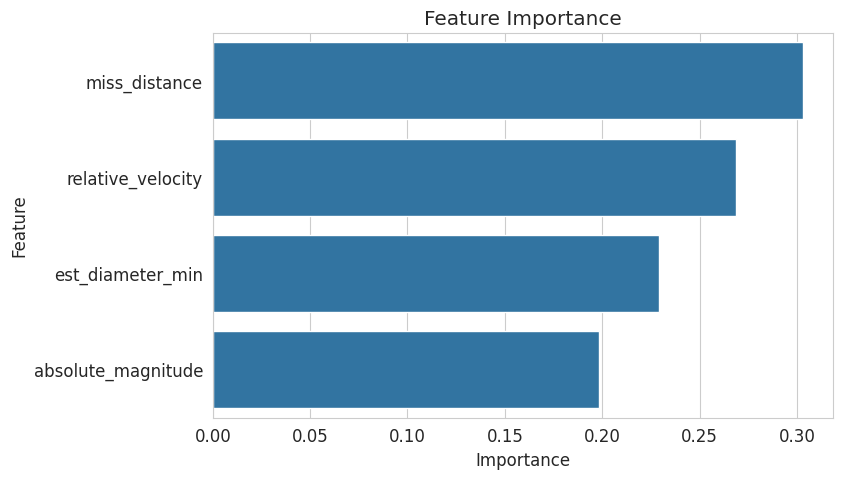

In [63]:
# ================================
# Plot Feature Importance
# ================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

## Feature Importance

Random Forest identifies the most influential features contributing to hazardous asteroid prediction.

These important variables will play a significant role in the final model.

In [64]:
# ================================
# Standardize Features
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,est_diameter_min,relative_velocity,miss_distance,absolute_magnitude
0,3.587284,-1.363913,0.795153,-2.348632
1,0.463529,1.009040,1.090357,-1.218735
2,1.991887,2.616983,0.569624,-1.968544
3,-0.103601,-0.921301,-0.520384,-0.458560
4,0.427378,-0.210697,0.412001,-1.187637


In [65]:
# ================================
# Verify Scaling
# ================================

X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
est_diameter_min,90836.0,-6.070073e-17,1.000006,-0.424855,-0.362389,-0.264864,0.053499,126.512573
relative_velocity,90836.0,-1.742017e-16,1.000006,-1.892353,-0.768900,-0.153275,0.587380,7.469341
miss_distance,90836.0,-1.239046e-16,1.000006,-1.658014,-0.888323,0.034898,0.871623,1.688093
absolute_magnitude,90836.0,4.552555e-16,1.000006,-4.940138,-0.755719,0.059742,0.750810,3.342317


#Phase 4: Model Development
##Objective

To develop and compare multiple supervised machine learning models for hazardous asteroid classification.

##Activities Performed
Split the dataset into training and testing sets.
Applied SMOTE to balance the target classes.
Trained Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost models.
Compared model performance using evaluation metrics.
##Outcome

Several predictive models were successfully developed, and Random Forest demonstrated the strongest overall performance for the classification task.

In [66]:
# ================================
# Train-Test Split
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (72668, 4)
Testing Samples : (18168, 4)


In [67]:
# ================================
# Check Class Distribution Before SMOTE
# ================================

print(y_train.value_counts())

hazardous
0    65596
1     7072
Name: count, dtype: int64


In [68]:
# ================================
# Apply SMOTE
# ================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,

    y_train

)

In [69]:
# ================================
# Verify SMOTE
# ================================

print(y_train_smote.value_counts())

hazardous
0    65596
1    65596
Name: count, dtype: int64


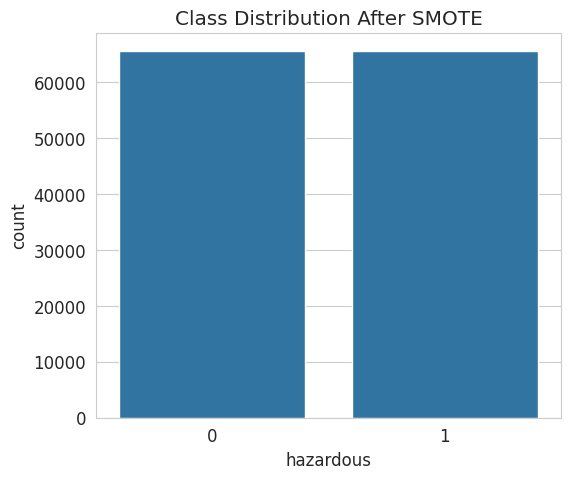

In [70]:
# ================================
# Plot After SMOTE
# ================================

plt.figure(figsize=(6,5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")

plt.show()

## Handling Class Imbalance

The original dataset contained significantly fewer hazardous asteroids than non-hazardous ones.

To avoid bias toward the majority class, Synthetic Minority Over-sampling Technique (SMOTE) was applied.

This generated synthetic samples of the minority class, resulting in a balanced training dataset.

In [71]:
# ================================
# Save Processed Data
# ================================

X_train_smote.to_csv("X_train.csv", index=False)

X_test.to_csv("X_test.csv", index=False)

print("Processed data saved.")

Processed data saved.


In [72]:
# ================================
# Import Required Libraries
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [73]:
import pandas as pd
import numpy as np

In [74]:
# ================================
# Create a Results Table
# ================================

results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC


In [75]:
# ================================
# Create Evaluation Function
# ================================

def evaluate_model(model, model_name):

    # Train
    model.fit(X_train_smote, y_train_smote)

    # Prediction
    y_pred = model.predict(X_test)

    # Probability (if available)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    # Metrics
    accuracy = accuracy_score(y_test,y_pred)

    precision = precision_score(y_test,y_pred)

    recall = recall_score(y_test,y_pred)

    f1 = f1_score(y_test,y_pred)

    roc = roc_auc_score(y_test,y_prob)

    print("="*60)

    print(model_name)

    print("="*60)

    print(classification_report(y_test,y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(model_name)

    plt.show()

    # Save Results
    global results

    results.loc[len(results)] = [
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

    return model

In [76]:
print("X_train exists:", 'X_train' in globals())
print("X_test exists:", 'X_test' in globals())
print("y_train exists:", 'y_train' in globals())
print("y_test exists:", 'y_test' in globals())

print("X_train_smote exists:", 'X_train_smote' in globals())
print("y_train_smote exists:", 'y_train_smote' in globals())

X_train exists: True
X_test exists: True
y_train exists: True
y_test exists: True
X_train_smote exists: True
y_train_smote exists: True


In [77]:
print("df exists:", 'df' in globals())

df exists: True


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.77      0.87     16400
           1       0.30      0.93      0.46      1768

    accuracy                           0.79     18168
   macro avg       0.65      0.85      0.66     18168
weighted avg       0.92      0.79      0.83     18168



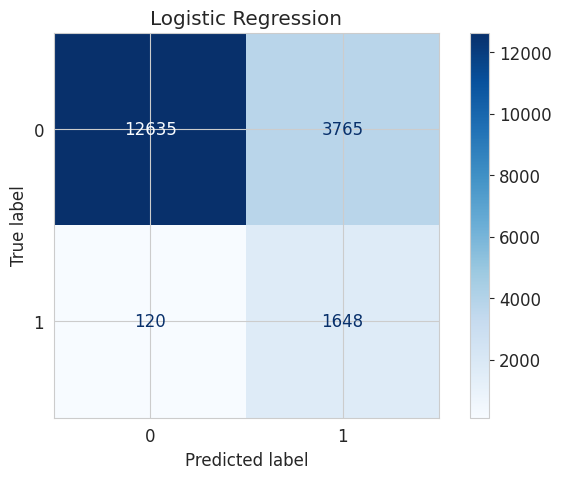

In [78]:
# Logistic Regression
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model = evaluate_model(
    logistic,
    "Logistic Regression"
)

Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     16400
           1       0.46      0.57      0.51      1768

    accuracy                           0.89     18168
   macro avg       0.71      0.75      0.72     18168
weighted avg       0.90      0.89      0.90     18168



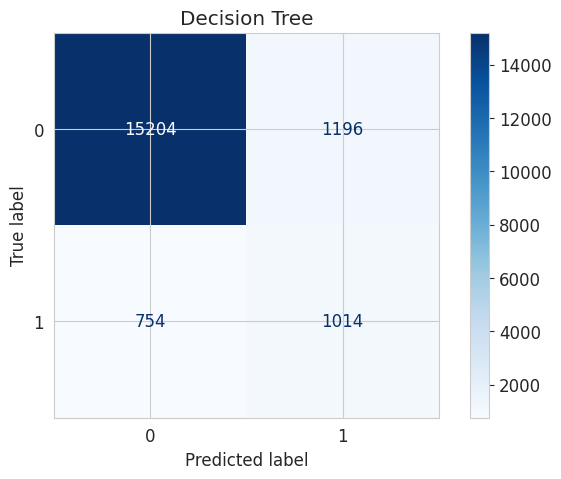

In [79]:
# Decision Tree

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model = evaluate_model(
    decision_tree,
    "Decision Tree"
)

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.93      0.94     16400
           1       0.49      0.62      0.54      1768

    accuracy                           0.90     18168
   macro avg       0.72      0.77      0.74     18168
weighted avg       0.91      0.90      0.90     18168



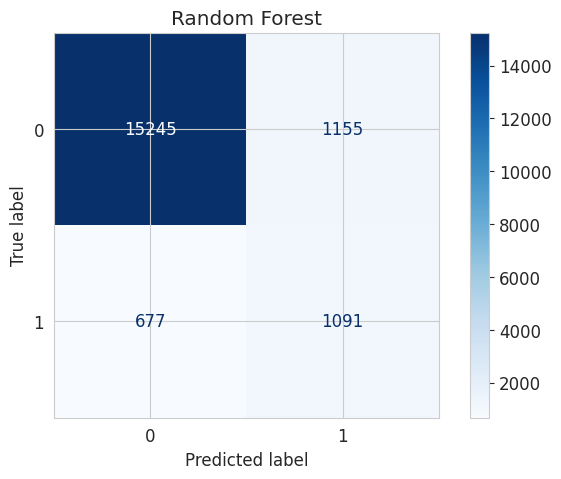

In [80]:
# Random Forest

random_forest = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

random_forest_model = evaluate_model(

    random_forest,

    "Random Forest"

)

Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      0.78      0.87     16400
           1       0.32      0.98      0.49      1768

    accuracy                           0.80     18168
   macro avg       0.66      0.88      0.68     18168
weighted avg       0.93      0.80      0.84     18168



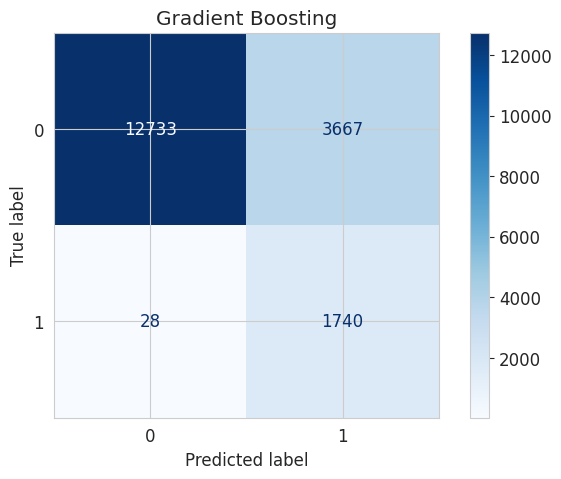

In [81]:
# Gradient Boosting

gradient_boost = GradientBoostingClassifier(
    random_state=42
)

gradient_model = evaluate_model(
    gradient_boost,
    "Gradient Boosting"
)

XGBoost
              precision    recall  f1-score   support

           0       0.97      0.85      0.91     16400
           1       0.36      0.77      0.49      1768

    accuracy                           0.84     18168
   macro avg       0.67      0.81      0.70     18168
weighted avg       0.91      0.84      0.87     18168



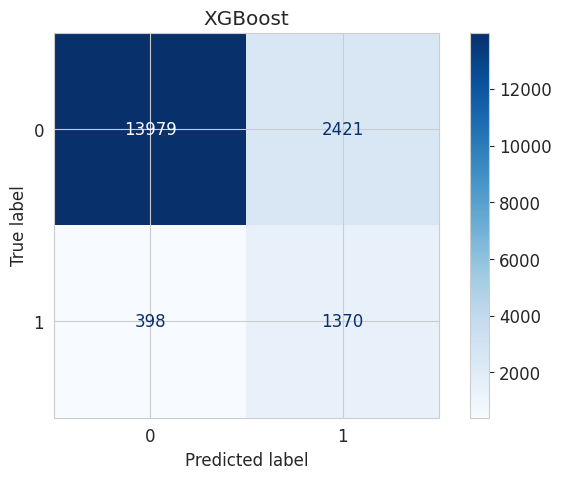

In [82]:
# XGBoost

xgb = XGBClassifier(

    random_state=42,

    eval_metric='logloss'

)

xgb_model = evaluate_model(

    xgb,

    "XGBoost"

)

In [83]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.786162,0.304452,0.932127,0.458989,0.879419
1,Decision Tree,0.892668,0.458824,0.573529,0.509804,0.750301
2,Random Forest,0.899163,0.485752,0.617081,0.543597,0.930094
3,Gradient Boosting,0.796620,0.321805,0.984163,0.485017,0.915748
4,XGBoost,0.844837,0.361382,0.774887,0.492894,0.917551


In [84]:
# Sort Models
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.899163,0.485752,0.617081,0.543597,0.930094
1,Decision Tree,0.892668,0.458824,0.573529,0.509804,0.750301
4,XGBoost,0.844837,0.361382,0.774887,0.492894,0.917551
3,Gradient Boosting,0.796620,0.321805,0.984163,0.485017,0.915748
0,Logistic Regression,0.786162,0.304452,0.932127,0.458989,0.879419


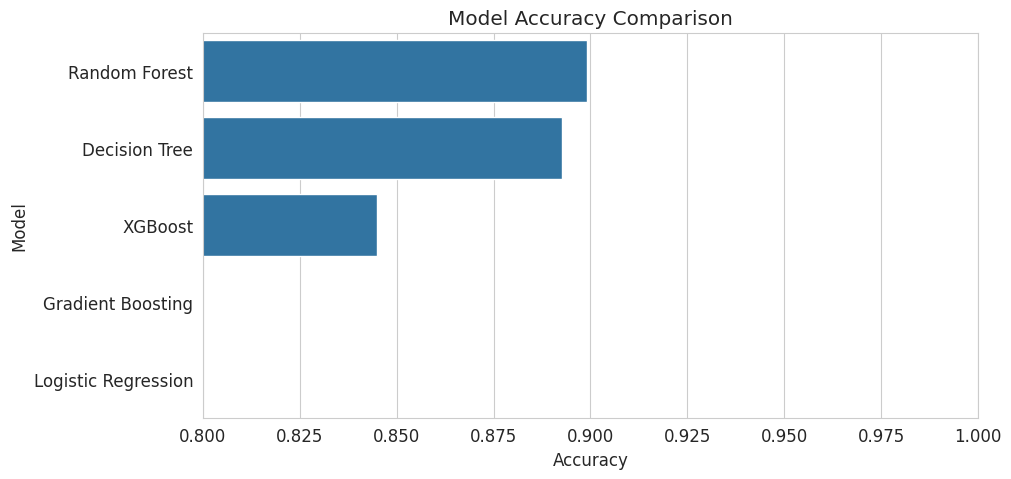

In [85]:
# Plot Accuracy Comparison

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0.8,1)

plt.show()

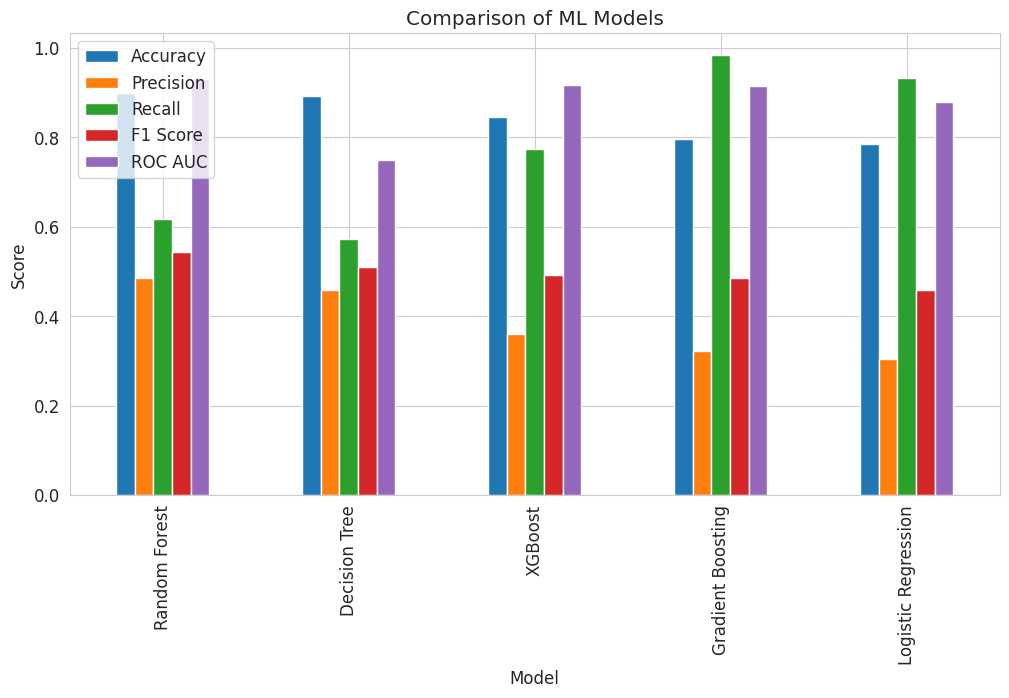

In [86]:
# Compare All Metrics
results.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of ML Models")

plt.ylabel("Score")

plt.show()

# Model Comparison Summary

Five supervised machine learning models were trained and evaluated.

The models compared include:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost

Performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The best-performing model will be selected for deployment.

In [87]:
# Select Best Model
best_model = random_forest_model

In [88]:
# Save Best Model
import joblib

joblib.dump(best_model, "asteroid_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [89]:
# Verify Saved Files
import os

print(os.listdir())

['.config', 'X_train.csv', 'scaler.pkl', 'neo.csv', 'X_test.csv', 'asteroid_model.pkl', 'cleaned_neo.csv', 'sample_data']


# Model Development Summary

Multiple supervised machine learning models were trained and compared.

Each model was evaluated using standard classification metrics.

The best-performing model was selected and saved for deployment.

Saving the trained model allows it to be reused without retraining, improving efficiency during deployment.

In [90]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [91]:
# Define Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [92]:
# Best Model
best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

best_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

              precision    recall  f1-score   support

           0       0.98      0.82      0.89     16400
           1       0.34      0.88      0.49      1768

    accuracy                           0.83     18168
   macro avg       0.66      0.85      0.69     18168
weighted avg       0.92      0.83      0.86     18168



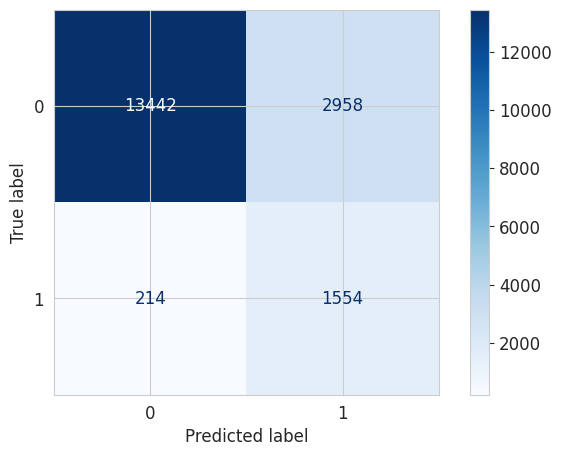

In [93]:
# Model Evaluation & Confusion Matrix
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.show()

In [94]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,est_diameter_min,0.521064
3,absolute_magnitude,0.339856
1,relative_velocity,0.079825
2,miss_distance,0.059254


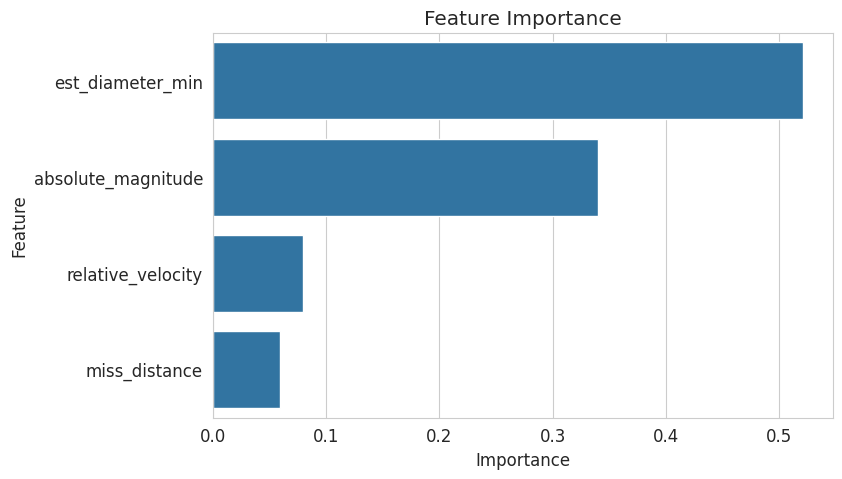

In [95]:
# Plot Feature Importance
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

#Phase 5: Model Evaluation
##Objective

To assess the effectiveness and reliability of the trained machine learning models using standard evaluation metrics.

##Activities Performed
Generated predictions on the testing dataset.
Computed Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
Visualized performance using a confusion matrix.
Compared model results to select the optimal classifier.
##Outcome

The evaluation confirmed that the Random Forest model achieved the most balanced and reliable classification performance.

# Feature Importance Analysis

The Random Forest model provides feature importance scores that indicate the contribution of each feature to the prediction process.

Higher importance values indicate stronger influence on hazardous asteroid classification.

In [96]:
!pip install shap

In [97]:
# ================================
# SHAP Explainability
# ================================

import shap

In [98]:
explainer = shap.TreeExplainer(best_model)

In [99]:
# Use only the first 500 test samples
X_test_sample = X_test[:500]

shap_values = explainer.shap_values(X_test_sample)


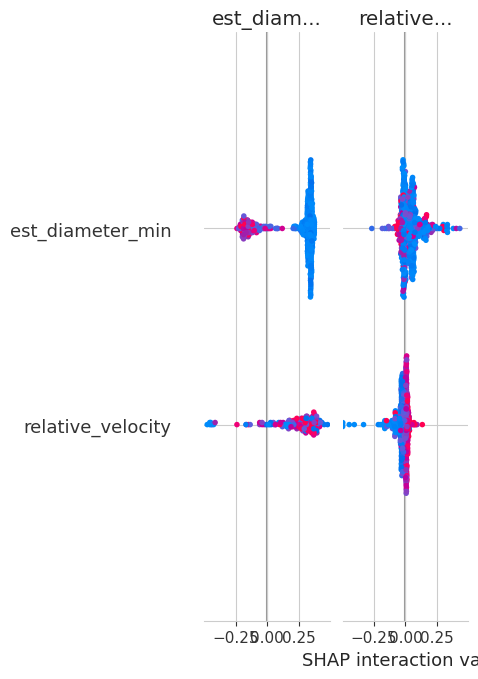

In [100]:
# ================================
# Summary Plot
# ================================

shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X.columns
)

# SHAP Interpretation

SHAP explains individual model predictions.

Features appearing at the top contribute most strongly to hazardous asteroid prediction.

Positive SHAP values increase the probability of the asteroid being classified as hazardous.

# Scientific Interpretation

The analysis indicates that asteroid diameter, relative velocity, miss distance, and absolute magnitude significantly influence hazard classification.

Large asteroids traveling at higher speeds while approaching Earth at shorter distances exhibit a higher probability of being hazardous.

The machine learning model successfully captures these relationships and provides reliable hazard predictions.

#Phase 6: Explainable Artificial Intelligence (XAI)
##Objective

To improve the interpretability of the prediction model by identifying the influence of each feature on the model's decisions.

##Activities Performed
Calculated feature importance scores.
Generated SHAP visualizations.
Interpreted the contribution of important features.
Examined how input variables affected predictions.
##Outcome

The model became more transparent, allowing a better understanding of the factors influencing hazardous asteroid predictions.

In [101]:
# ================================
# Save Model
# ================================

import joblib

joblib.dump(best_model, "asteroid_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [102]:
import os

os.listdir()

['.config',
 'X_train.csv',
 'scaler.pkl',
 'neo.csv',
 'X_test.csv',
 'asteroid_model.pkl',
 'cleaned_neo.csv',
 'sample_data']

In [109]:
import streamlit as st
import pandas as pd
import joblib

# Load model and scaler
model = joblib.load("asteroid_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Hazardous Asteroid Prediction")

st.write("Enter asteroid details below:")

est_diameter_min = st.number_input("Estimated Minimum Diameter")
relative_velocity = st.number_input("Relative Velocity")
miss_distance = st.number_input("Miss Distance")
absolute_magnitude = st.number_input("Absolute Magnitude")

if st.button("Predict"):

    sample = pd.DataFrame({
        "est_diameter_min":[est_diameter_min],
        "relative_velocity":[relative_velocity],
        "miss_distance":[miss_distance],
        "absolute_magnitude":[absolute_magnitude]
    })

    sample = scaler.transform(sample)

    prediction = model.predict(sample)

    if prediction[0] == 1:
        st.error("Hazardous Asteroid")
    else:
        st.success("Non-Hazardous Asteroid")

2026-07-13 09:24:59.634 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 09:25:00.059 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-13 09:25:00.063 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 09:25:00.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 09:25:00.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 09:25:00.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 09:25:00.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 09:25:00.079 Thread 'MainThread': mi

In [110]:
!ls

asteroid_model.pkl  neo.csv	 scaler.pkl  X_train.csv
cleaned_neo.csv     sample_data  X_test.csv


In [111]:
# ================================
# Create requirements.txt
# ================================

%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib
xgboost
imbalanced-learn
matplotlib
seaborn

Writing requirements.txt


In [113]:
# ================================
# Download the Files
# ================================

from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("asteroid_model.pkl")
files.download("scaler.pkl")

FileNotFoundError: Cannot find file: app.py

# Project Summary

This project focuses on developing a machine learning-based system to predict whether a Near-Earth Object (NEO) is hazardous using its physical and orbital characteristics. The dataset was preprocessed by handling missing values, encoding categorical features, scaling numerical attributes, and balancing the target classes using the SMOTE technique. Exploratory Data Analysis (EDA) was performed to understand data distributions, feature relationships, and class imbalance.

Multiple supervised machine learning algorithms, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost, were trained and evaluated using performance metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Among the evaluated models, the Random Forest Classifier achieved the best overall performance and was selected as the final prediction model.

To improve model interpretability, Explainable Artificial Intelligence (XAI) techniques such as Feature Importance and SHAP analysis were applied. Finally, the trained model was deployed as a Streamlit web application, enabling users to enter asteroid parameters and receive real-time hazard predictions. The project demonstrates the practical application of machine learning in supporting space research and intelligent decision-making for planetary defense.

In [108]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 113.1 MB/s eta 0:00:00


# Local Deployment using Streamlit

After training and saving the machine learning model, a simple web application was developed using **Streamlit** to enable real-time hazardous asteroid prediction.

## Files Required

Ensure the following files are present in the same project directory:

- `app.py`
- `asteroid_model.pkl`
- `scaler.pkl`
- `requirements.txt`

## Step 1: Clone or Download the Project

Download all the project files from Google Colab or clone the GitHub repository (if available).

## Step 2: Install Python

Install **Python 3.12** (recommended) from the official Python website:

https://www.python.org/downloads/

During installation, enable the **"Add Python to PATH"** option.

## Step 3: Install Required Libraries

Open Command Prompt or PowerShell in the project folder and execute:

```bash
python -m pip install -r requirements.txt
```

This installs all the dependencies required for the application.

## Step 4: Run the Streamlit Application

Execute the following command:

```bash
python -m streamlit run app.py
```

or

```bash
streamlit run app.py
```

## Step 5: Access the Web Application

After the application starts, Streamlit automatically opens the application in the default web browser.

If it does not open automatically, visit the URL displayed in the terminal, which is typically:

```
http://localhost:8501
```

## Application Workflow

1. Enter the asteroid characteristics:
   - Estimated Minimum Diameter
   - Relative Velocity
   - Miss Distance
   - Absolute Magnitude

2. Click the **Predict** button.

3. The application loads the trained Random Forest model and predicts whether the asteroid is:

- **Hazardous Asteroid**
- **Non-Hazardous Asteroid**

#Phase 8: Conclusion
##Objective

To summarize the overall project findings and evaluate the effectiveness of the developed prediction system.

##Activities Performed
Reviewed the complete machine learning workflow.
Compared the performance of different algorithms.
Identified the best-performing model.
Highlighted the practical significance of the developed system.
##Outcome

The project successfully delivered an end-to-end machine learning solution capable of accurately classifying hazardous asteroids and demonstrating the practical application of predictive analytics in space science.